## Micrograd Tensor Addition

### 1. Imports

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

### 2. Building out Tensor Class

In [2]:
class Tensor:
  def __init__(self, data, _children=(), _op=''):
    self.data = np.array(data, dtype=np.float32)
    self.grad = np.zeros_like(self.data)
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op

  def __repr__(self):
    return f"Tensor({self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data + other.data, (self, other), "+")
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data * other.data, (self, other), "*")
    return out

  def __matmul__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data @ other.data, (self, other), "@")
    return out

  def __neg__(self):
    return Tensor(self.data * -1, (self,), "neg")

  def __sub__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data - other.data, (self, other), "-")
    return out

  def __truediv__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data / other.data, (self, other), "/")
    return out

  def transpose(self):
    out = Tensor(self.data.T, (self,), "T")
    return out

In [3]:
a = Tensor([1, 2, 3])

In [4]:
b = Tensor([1, 2, 3])
a + b

Tensor([2. 4. 6.])

In [5]:
c = Tensor([1])
a + c

Tensor([2. 3. 4.])

In [6]:
a = Tensor([1, 2, 3])
b = Tensor([1, 2, 3])
c = Tensor([1, 2, 3])

d = (a + b) * c
d

Tensor([ 2.  8. 18.])

In [7]:
from graphviz import Digraph
import numpy as np

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges


def _format_tensor_data(arr):
    """Formats 0D/1D/ND NumPy arrays cleanly for Graphviz record labels."""
    if arr is None:
        return "None"

    # 0D scalars or single-element arrays
    if arr.ndim == 0 or arr.size == 1:
        return f"{float(arr.squeeze()):.4f}"

    # Multi-element arrays: display shape and compact array values
    shape_str = f"shape {arr.shape}"
    arr_str = np.array2string(arr, precision=2, suppress_small=True, separator=', ')
    clean_arr = arr_str.replace('\n', ' ')  # avoid breaking Graphviz record lines
    return f"{shape_str} \\n {clean_arr}"


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))

        # Include label if available on the instance
        label_prefix = f"{n.label} | " if hasattr(n, 'label') and n.label else ""

        data_str = _format_tensor_data(n.data)
        grad_str = _format_tensor_data(n.grad)

        # Construct Graphviz record label
        node_label = f"{{{label_prefix}data: {data_str} | grad: {grad_str}}}"
        dot.node(name=uid, label=node_label, shape='record')

        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [8]:
a = Tensor([1, 2, 3]); a.label = 'a'
b = Tensor([1, 2, 3]); b.label = 'b'
c = Tensor([1, 2, 3]); c.label = 'c'

d = (a + b) @ c; d.label = 'd'
d

Tensor(28.0)

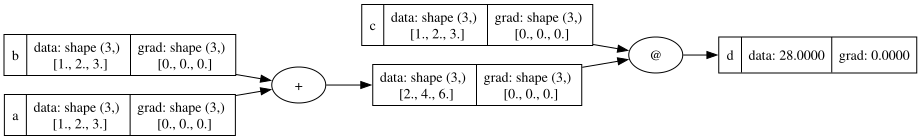

In [9]:
draw_dot(d)

In [10]:
d._prev

{Tensor([1. 2. 3.]), Tensor([2. 4. 6.])}

In [11]:
d._op

'@'

In [12]:
a = Tensor([[1], [2]]); a.label = 'a'
b = Tensor([[1, 2, 3]]); b.label = 'b'
c = Tensor([[1, 0, 0], [0, 1, 0]]); c.label = 'c'
d = a @ b; d.label = 'd'
e = c + d; e.label = 'e'
f = Tensor([[1, 1, 1, 1], [1, 1, 1, 1], [1, 1, 1, 1]]); f.label = 'f'
L = e @ f; L.label = 'L'
L

Tensor([[ 7.  7.  7.  7.]
 [13. 13. 13. 13.]])

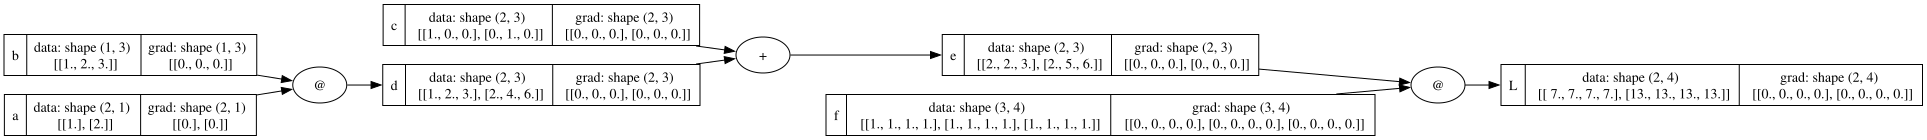

In [13]:
draw_dot(L)

### 3. Manual Backpropagation

In [14]:
L.grad = Tensor(np.ones_like(L.data))
L.grad

Tensor([[1. 1. 1. 1.]
 [1. 1. 1. 1.]])

In [15]:
# dL/de = ?
# L.grad shape = (2,4), e.grad shape = (2,3) f.grad shape = (3,4)
# dL/de = L.grad @ f.transpose()

e.grad = L.grad @ f.transpose()
e.grad

Tensor([[4. 4. 4.]
 [4. 4. 4.]])

In [16]:
# dL/df = ?
# L.grad shape = (2,4), e.grad shape = (2,3) f.grad shape = (3,4)
# dL/df = e.transpose() @ L.grad

f.grad = e.transpose() @ L.grad
f.grad

Tensor([[4. 4. 4. 4.]
 [7. 7. 7. 7.]
 [9. 9. 9. 9.]])

In [17]:
# dL/dc = ?
# same as with numbers -> c.grad = e.grad * 1.0

c.grad = e.grad * 1.0
c.grad

Tensor([[4. 4. 4.]
 [4. 4. 4.]])

In [18]:
d.grad = e.grad * 1.0
d.grad

Tensor([[4. 4. 4.]
 [4. 4. 4.]])

In [19]:
# dL/da = ?
# a.grad = d.grad @ b.transpose()

a.grad = d.grad @ b.transpose()
a.grad

Tensor([[24.]
 [24.]])

In [20]:
# dL/db = ?
# b.grad = a.transpose() @ d.grad

b.grad = a.transpose() @ d.grad
b.grad

Tensor([[12. 12. 12.]])

### 4. Automating Backpropagation

In [21]:
class Tensor:
  def __init__(self, data, _children=(), _op=''):
    self.data = np.array(data, dtype=np.float32)
    self.grad = np.zeros_like(self.data)
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op

  def __repr__(self):
    return f"Tensor({self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data + other.data, (self, other), "+")

    def _backward():
      self.grad += out.grad * 1.0
      other.grad += out.grad * 1.0
    out._backward = _backward
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data * other.data, (self, other), "*")

    def _backward():
      self.grad += out.grad * other.data
      other.grad += out.grad * self.data

    out._backward = _backward
    return out

  def __matmul__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data @ other.data, (self, other), "@")

    def _backward():
      self.grad += out.grad @ other.data.T
      other.grad += self.data.T @ out.grad
    out._backward = _backward
    return out

  def __neg__(self):
    return Tensor(self.data * -1, (self,), "neg")

  def __sub__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data - other.data, (self, other), "-")
    return out

  def __truediv__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data / other.data, (self, other), "/")
    return out

  def transpose(self):
    out = Tensor(self.data.T, (self,), "T")
    return out

In [22]:
a = Tensor([[1], [2]])
b = Tensor([[1, 2, 3]])
c = Tensor([[1, 0, 0], [0, 1, 0]])
d = a @ b
e = c + d
f = Tensor([[1, 1, 1, 1], [1, 1, 1, 1], [1, 1, 1, 1]])
L = e @ f
L

Tensor([[ 7.  7.  7.  7.]
 [13. 13. 13. 13.]])

In [23]:
L.grad = np.ones_like(L.data)
L._backward()

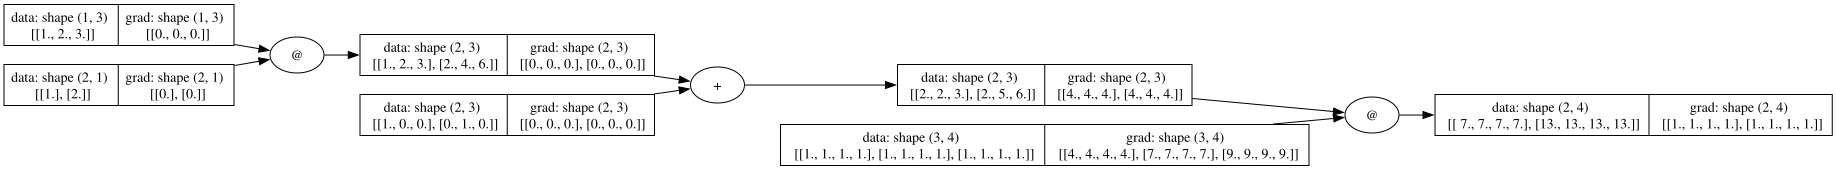

In [24]:
draw_dot(L)

In [25]:
# Topological Sort
#
# We are using topological sort L->R as we want to get graph elements from left to right inside a list
# and each element only comes after its inputs
# That way we can automate backpropagation
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)

build_topo(L)
topo

[Tensor([[1. 0. 0.]
  [0. 1. 0.]]),
 Tensor([[1.]
  [2.]]),
 Tensor([[1. 2. 3.]]),
 Tensor([[1. 2. 3.]
  [2. 4. 6.]]),
 Tensor([[2. 2. 3.]
  [2. 5. 6.]]),
 Tensor([[1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]]),
 Tensor([[ 7.  7.  7.  7.]
  [13. 13. 13. 13.]])]

In [26]:
def unbroadcast(grad, shape):
  """Reduces a broadcasted gradient back to the original shape.

  Args:
    grad: The broadcasted gradient, shaped like the output of the forward
      operation.
    shape: The original shape of the operand that was broadcasted.

  Returns:
    The reduced gradient, shaped like ``shape``.
  """

  while len(grad.shape) > len(shape):
    grad = grad.sum(axis=0)
  for axis, size in enumerate(shape):
    if size == 1:
      grad = grad.sum(axis=axis, keepdims=True)
  return grad

In [27]:
class Tensor:
  def __init__(self, data, _children=(), _op=''):
    self.data = np.array(data, dtype=np.float32)
    self.grad = np.zeros_like(self.data)
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op

  def __repr__(self):
    return f"Tensor({self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data + other.data, (self, other), "+")

    def _backward():
      self.grad += unbroadcast(out.grad, self.data.shape)
      other.grad += unbroadcast(out.grad, other.data.shape)
    out._backward = _backward
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data * other.data, (self, other), "*")

    def _backward():
      self.grad += unbroadcast(out.grad * other.data, self.data.shape)
      other.grad += unbroadcast(out.grad * self.data, other.data.shape)

    out._backward = _backward
    return out

  def __matmul__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data @ other.data, (self, other), "@")

    def _backward():
      self.grad += out.grad @ other.data.T
      other.grad += self.data.T @ out.grad
    out._backward = _backward
    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Tensor(self.data**other, (self,), f"**{other}")

    def _backward():
      self.grad += out.grad * (other * self.data**(other-1))
    out._backward = _backward
    return out

  def __neg__(self):
    out = Tensor(self.data * -1, (self,), "neg")

    def _backward():
      self.grad += -out.grad
    out._backward = _backward
    return out

  def __sub__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data - other.data, (self, other), "-")

    def _backward():
      self.grad += unbroadcast(out.grad, self.data.shape)
      other.grad += unbroadcast(-out.grad, other.data.shape)
    out._backward = _backward
    return out

  def __truediv__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data / other.data, (self, other), "/")

    def _backward():
      self.grad += unbroadcast(out.grad / other.data, self.data.shape)
      other.grad += unbroadcast(-out.grad * self.data / other.data**2, other.data.shape)
    out._backward = _backward
    return out

  def transpose(self):
    out = Tensor(self.data.T, (self,), "T")

    def _backward():
      self.grad += out.grad.T
    out._backward = _backward
    return out

  def sum(self):
    out = Tensor(self.data.sum(), (self,), "sum")

    def _backward():
      self.grad += out.grad
    out._backward = _backward
    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)

    build_topo(self)

    self.grad = np.ones_like(self.data)
    for node in reversed(topo):
      node._backward()

  def relu(self):
    out = Tensor(np.maximum(self.data, 0), (self,), "ReLU")
    def _backward():
      self.grad += out.grad * (self.data > 0)
    out._backward = _backward
    return out

  def tanh(self):
    out = Tensor(np.tanh(self.data), (self,), "tanh")
    def _backward():
      self.grad += out.grad * (1 - out.data ** 2)
    out._backward = _backward
    return out

In [28]:
a = Tensor([[1], [2]])
b = Tensor([[1, 2, 3]])
c = Tensor([[1, 0, 0], [0, 1, 0]])
d = a @ b
e = c + d
f = Tensor([[1, 1, 1, 1], [1, 1, 1, 1], [1, 1, 1, 1]])
L = e @ f
L

Tensor([[ 7.  7.  7.  7.]
 [13. 13. 13. 13.]])

In [29]:
L.backward()

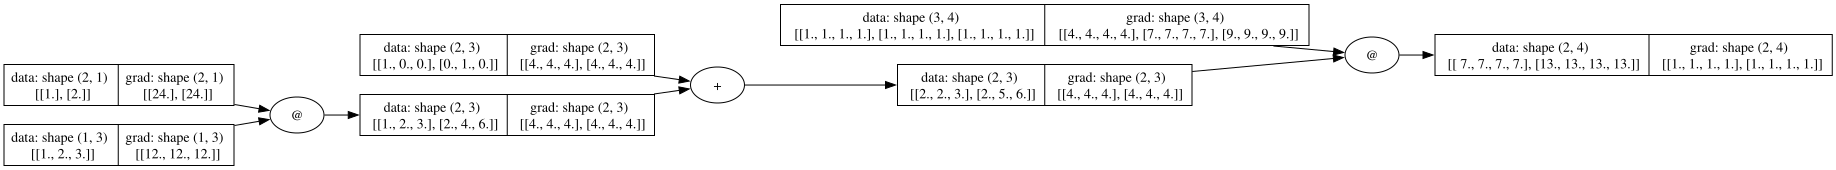

In [30]:
draw_dot(L)

### 5. Backpropagation on Tensors in PyTorch

In [31]:
import torch

a = torch.tensor([[1.0], [2.0]], requires_grad=True)
b = torch.tensor([[1.0, 2.0, 3.0]], requires_grad=True)
c = torch.tensor([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]], requires_grad=True)
d = a @ b
e = c + d
f = torch.tensor([[1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0]], requires_grad=True)
L = e @ f

L.backward(torch.ones_like(L))

print('---')
print("a.grad:\n", a.grad)
print("b.grad:\n", b.grad)
print("c.grad:\n", c.grad)
print("f.grad:\n", f.grad)

---
a.grad:
 tensor([[24.],
        [24.]])
b.grad:
 tensor([[12., 12., 12.]])
c.grad:
 tensor([[4., 4., 4.],
        [4., 4., 4.]])
f.grad:
 tensor([[4., 4., 4., 4.],
        [7., 7., 7., 7.],
        [9., 9., 9., 9.]])


### 6. Building MLP using Tensor Class

In [32]:
class TensorNeuron:
  def __init__(self, input_size: int):
    self.w = Tensor(np.random.uniform(low=-1, high=1, size=(input_size, 1)).flatten())
    self.b = Tensor(np.random.uniform(low=-1, high=1))

  def __call__(self, x):
    if not isinstance(x, Tensor):
      x = Tensor(x)
    act = (x * self.w).sum() + self.b
    out = act.tanh()
    return out

  def parameters(self):
    return [self.w, self.b]

In [33]:
x = [1, 2, 3]
n = TensorNeuron(3)

n.w

Tensor([ 0.30641964  0.24657239 -0.16119109])

In [34]:
n(x)._prev

{Tensor(1.2978367805480957)}

In [35]:
n.parameters()

[Tensor([ 0.30641964  0.24657239 -0.16119109]), Tensor(0.9818455576896667)]

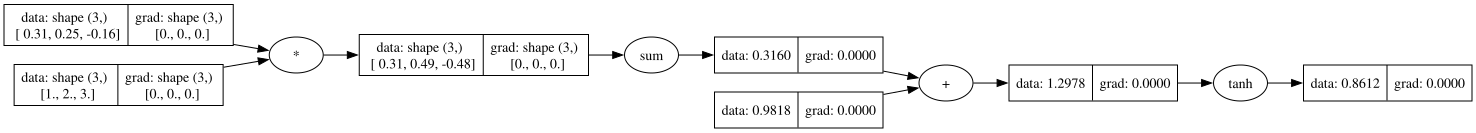

In [36]:
draw_dot(n(x))

In [37]:
class TensorLayer:
  def __init__(self, input_size: int, output_size: int):
    self.w = Tensor(np.random.uniform(-1, 1, size=(input_size, output_size)))
    self.b = Tensor(np.random.uniform(-1, 1, size=output_size))

  def __call__(self, x):
    if not isinstance(x, Tensor):
      x = Tensor(x)
    acts = x @ self.w + self.b
    # One tanh over the whole matrix, where TensorNeuron applies one per neuron
    outs = acts.tanh()
    return outs

  def parameters(self):
    return [self.w, self.b]

In [38]:
x = [1, 2]
n = TensorLayer(2,3)

n(x)

Tensor([-0.84605956  0.9532996  -0.42118564])

In [39]:
n.parameters()

[Tensor([[-0.6664541  -0.14845641  0.8538723 ]
  [-0.06733324  0.9087768  -0.5813989 ]]),
 Tensor([-0.44100082  0.19766414 -0.140207  ])]

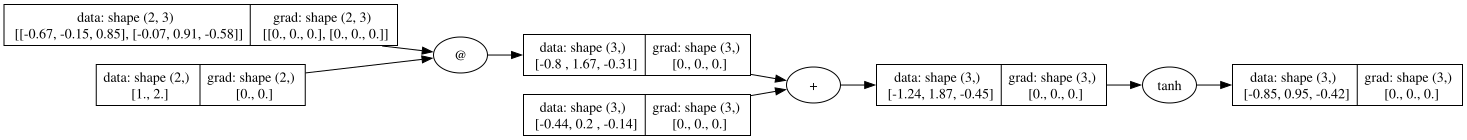

In [40]:
draw_dot(n(x))

In [41]:
from typing import List

class TensorMLP:
  def __init__(self, input_size: int, output_sizes: List[int]):
    sz = [input_size] + output_sizes
    self.layers = [TensorLayer(sz[i], sz[i+1]) for i in range(len(output_sizes))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)

    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [42]:
x = [1, 2, 3]
n = TensorMLP(3, [4, 4, 1])

n(x)

Tensor([0.7612472])

In [43]:
n.parameters()

[Tensor([[ 0.175707   -0.21588266 -0.90200925  0.3402974 ]
  [-0.4465686   0.6394586  -0.43667504 -0.9865355 ]
  [ 0.04367322 -0.9270157  -0.380856   -0.16631672]]),
 Tensor([ 0.34041196  0.7701855  -0.6313245   0.72195715]),
 Tensor([[ 0.8993026   0.6408361   0.6771158   0.22537239]
  [-0.34976125 -0.41752118  0.70188814  0.87396353]
  [ 0.6646516  -0.9160319  -0.92162836 -0.11674583]
  [ 0.6822722  -0.6427336   0.09435511  0.15169473]]),
 Tensor([-0.37569955  0.4282741  -0.3353516   0.5683898 ]),
 Tensor([[ 0.38052064]
  [ 0.28768447]
  [-0.65429217]
  [-0.01362754]]),
 Tensor([0.95239323])]

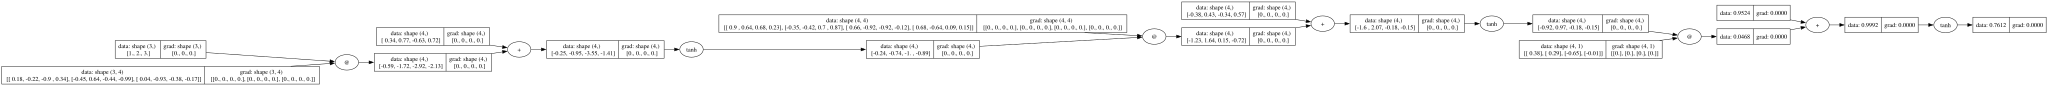

In [44]:
draw_dot(n(x))

### 7. Manual Gradient Descent

In [45]:
xs = Tensor([
    [2, 3, -1],
    [3, -1, 0.5],
    [0.5, 1, 1],
    [1, 1, -1]
])

ys = Tensor([[1], [-1], [-1], [1]])

In [46]:
ypreds = n(xs)
ypreds

Tensor([[0.34855023]
 [0.77288216]
 [0.40952748]
 [0.25126955]])

In [47]:
# MSE Loss
loss = (ypreds - ys)**2
loss

Tensor([[0.42438683]
 [3.1431115 ]
 [1.9867679 ]
 [0.56059724]])

In [48]:
loss.sum()

Tensor(6.114863395690918)

In [49]:
loss.backward()

In [50]:
n.layers[0].w.data

array([[ 0.175707  , -0.21588266, -0.90200925,  0.3402974 ],
       [-0.4465686 ,  0.6394586 , -0.43667504, -0.9865355 ],
       [ 0.04367322, -0.9270157 , -0.380856  , -0.16631672]],
      dtype=float32)

In [51]:
n.layers[0].w.grad

array([[-0.04050751, -1.0422784 ,  0.02813412,  0.10067707],
       [-0.01958878, -0.4035124 ,  0.03838863,  0.09940019],
       [-0.268982  , -0.81772035,  0.09451649, -0.10796086]],
      dtype=float32)

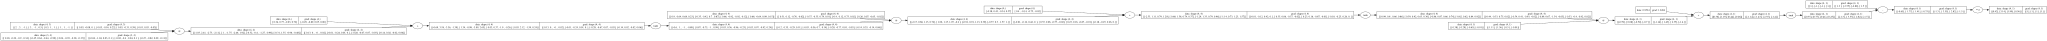

In [52]:
draw_dot(loss)

In [53]:
for p in n.parameters():
  p.data += -0.01 * p.grad

In [54]:
n.layers[0].w.data

array([[ 0.17611207, -0.20545988, -0.9022906 ,  0.33929062],
       [-0.44637272,  0.6434937 , -0.43705893, -0.9875295 ],
       [ 0.04636304, -0.9188385 , -0.38180116, -0.16523711]],
      dtype=float32)

In [55]:
ypreds = n(xs)

loss = (ypreds - ys)**2
loss.sum()

Tensor(5.994708061218262)

In [56]:
loss.backward()

In [57]:
for p in n.parameters():
  p.data += -0.01 * p.grad

In [58]:
ypreds = n(xs)

loss = (ypreds - ys)**2
loss.sum()

Tensor(5.741654396057129)

In [59]:
ypreds

Tensor([[0.3076932 ]
 [0.6891997 ]
 [0.32887056]
 [0.19808139]])

### 8. Automating Gradient Descent 

In [60]:
class SGD:
  def __init__(self, parameters, lr=0.01):
    self.parameters = parameters
    self.lr = lr

  def step(self):
    for p in self.parameters:
      p.data += -self.lr * p.grad

  def zero_grad(self):
    for p in self.parameters:
      p.grad = np.zeros_like(p.data)

In [61]:
n = TensorMLP(3, [4, 4, 1])
optimizer = SGD(n.parameters(), lr=0.01)
n

In [62]:
for k in range(20):
    ypreds = n(xs)
    loss = ((ypreds - ys)**2).sum()

    optimizer.zero_grad()  # Reset gradients before backward pass
    loss.backward()

    optimizer.step()

    print(f"Step {k+1}, Loss: {loss.data:.4f}")

Step 1, Loss: 3.9591
Step 2, Loss: 3.4451
Step 3, Loss: 3.1794
Step 4, Loss: 3.0018
Step 5, Loss: 2.8278
Step 6, Loss: 2.6375
Step 7, Loss: 2.4310
Step 8, Loss: 2.2162
Step 9, Loss: 2.0033
Step 10, Loss: 1.8010
Step 11, Loss: 1.6149
Step 12, Loss: 1.4469
Step 13, Loss: 1.2970
Step 14, Loss: 1.1640
Step 15, Loss: 1.0466
Step 16, Loss: 0.9433
Step 17, Loss: 0.8526
Step 18, Loss: 0.7730
Step 19, Loss: 0.7031
Step 20, Loss: 0.6419


In [63]:
ypreds

Tensor([[ 0.6517017]
 [-0.7229789]
 [-0.5150704]
 [ 0.5432268]])